# Disease-relevant optimization subgraph

The full gene-interaction graph contains many genes that are not annotated to any disease in the available disease collection. Removing those genes can reduce the graph size and accelerate prioritization algorithms, but an unannotated gene may still be an important connector or a highly ranked candidate.

This notebook constructs a conservative optimization subgraph. First, each graph gene receives a **disease relevance score** equal to the number of disease gene sets containing it. Genes with score zero are removal candidates. Next, genes ranked in the top 1,000 for breast neoplasms in any saved benchmark method or run are protected, even if their annotation score is zero. The final subgraph removes only zero-relevance genes that were not protected. Consequently, every annotated disease gene is retained.

In [1]:
import pickle
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if not (project_root / "bioGraph").is_dir():
    raise FileNotFoundError(
        "Start Jupyter from the repository root or the notebooks directory."
    )
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from bioGraph.data.loading import load_disease_genes, load_ppi_graph
from bioGraph.methods.utils import scores_to_ranking

data_dir = project_root / "data" / "raw"
results_dir = project_root / "outputs" / "results"
graph = load_ppi_graph(data_dir / "PPI202207.txt")
diseases = load_disease_genes(data_dir / "pcbi.1004120.s004.txt")
print(
    f"Loaded {graph.number_of_nodes():,} genes, "
    f"{graph.number_of_edges():,} interactions, and {len(diseases)} diseases."
)

Loaded 17,504 genes, 354,647 interactions, and 70 diseases.


## Disease relevance of graph genes

The score below counts distinct disease sets, not repeated occurrences within a disease record. A score of zero means that the gene is not a known gene for any disease in this dataset.

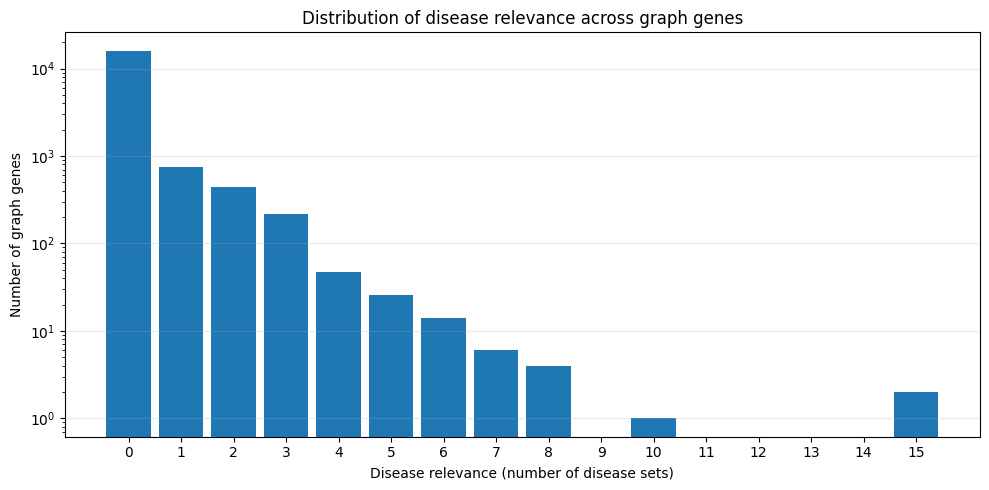

Genes with disease relevance 0: 15,983


In [3]:
disease_relevance = Counter()
graph_genes = set(graph)
for disease_genes in diseases.values():
    disease_relevance.update(set(disease_genes) & graph_genes)

relevance_by_gene = {gene: disease_relevance.get(gene, 0) for gene in graph}
zero_relevance_genes = sorted(
    gene for gene, relevance in relevance_by_gene.items() if relevance == 0
)

max_relevance = max(relevance_by_gene.values(), default=0)
bins = range(max_relevance + 2)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(relevance_by_gene.values(), bins=bins, align="left", rwidth=0.85)
ax.set_xlabel("Disease relevance (number of disease sets)")
ax.set_ylabel("Number of graph genes")
ax.set_title("Distribution of disease relevance across graph genes")
ax.set_xticks(range(max_relevance + 1))
ax.grid(axis="y", alpha=0.25)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

print(f"Genes with disease relevance 0: {len(zero_relevance_genes):,}")

## Protect top-ranked breast-neoplasms candidates

The benchmark artifact contains full score vectors and the outer training genes for each run. Rankings are reconstructed while excluding the run's training genes. To avoid removing potentially useful candidates, this notebook protects the union of the top 1,000 genes across **all methods and all breast-neoplasms runs**.

In [9]:
artifact_candidates = [
    results_dir / "results_methods_by_6disease_75split.pkl",
    results_dir / "results_methods_by_6disease.pkl",
]
artifact_path = next((path for path in artifact_candidates if path.is_file()), None)
if artifact_path is None:
    expected = ", ".join(str(path) for path in artifact_candidates)
    raise FileNotFoundError(f"Could not find a six-disease result file: {expected}")

with artifact_path.open("rb") as handle:
    benchmark_results = pickle.load(handle)

nodelist = benchmark_results["nodelist"]
breast_runs = [
    row for row in benchmark_results["runs"]
    if row["disease"] == "breast neoplasms"
]
if not breast_runs:
    raise ValueError("The benchmark artifact has no breast-neoplasms runs.")

top_k = 1000
protected_top_genes = set()
for row in breast_runs:
    for scores in row["scores"].values():
        ranking = scores_to_ranking(scores, nodelist, graph, row["train_genes"])
        protected_top_genes.update(item["gene_id"] for item in ranking[:top_k])

protected_zero_relevance_genes = sorted(
    set(zero_relevance_genes) & protected_top_genes
)
genes_to_remove = sorted(set(zero_relevance_genes) - protected_top_genes)

print(f"Loaded: {artifact_path.name}")
print(f"Breast-neoplasms runs: {len(breast_runs)}")
print(f"Unique genes protected by a top-{top_k:,} ranking: {len(protected_top_genes):,}")
print(
    "Zero-relevance genes protected by ranking: "
    f"{len(protected_zero_relevance_genes):,}"
)
print(f"Zero-relevance genes remaining for removal: {len(genes_to_remove):,}")

Loaded: results_methods_by_6disease_75split.pkl
Breast-neoplasms runs: 30
Unique genes protected by a top-1,000 ranking: 4,411
Zero-relevance genes protected by ranking: 3,856
Zero-relevance genes remaining for removal: 12,127


## Construct and validate the optimization subgraph

Only `genes_to_remove` are dropped. Every known disease gene present in the original graph must therefore remain, as must every protected top-ranked candidate.

In [10]:
retained_genes = graph_genes - set(genes_to_remove)
optimization_subgraph = graph.subgraph(retained_genes).copy()

known_disease_genes_in_graph = set().union(
    *(set(genes) & graph_genes for genes in diseases.values())
)
assert known_disease_genes_in_graph <= set(optimization_subgraph)
assert protected_top_genes <= set(optimization_subgraph)
assert not (set(genes_to_remove) & set(optimization_subgraph))

node_reduction = 1 - optimization_subgraph.number_of_nodes() / graph.number_of_nodes()
edge_reduction = 1 - optimization_subgraph.number_of_edges() / graph.number_of_edges()
print(f"Original graph: {graph.number_of_nodes():,} nodes, {graph.number_of_edges():,} edges")
print(
    f"Optimization subgraph: {optimization_subgraph.number_of_nodes():,} nodes, "
    f"{optimization_subgraph.number_of_edges():,} edges"
)
print(f"Node reduction: {node_reduction:.1%}")
print(f"Edge reduction: {edge_reduction:.1%}")

Original graph: 17,504 nodes, 354,647 edges
Optimization subgraph: 5,377 nodes, 94,987 edges
Node reduction: 69.3%
Edge reduction: 73.2%


The variables `optimization_subgraph`, `genes_to_remove`, `zero_relevance_genes`, and `protected_zero_relevance_genes` are now available for downstream experiments. To compare runtime fairly, reuse the same outer train/test gene identities when benchmarking the full graph and this subgraph.

In [11]:
# Save in the same four-column, tab-separated format as the original PPI file.
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)
subgraph_path = processed_dir / "subgraph_5377.txt"

with subgraph_path.open("w", encoding="utf-8") as handle:
    for gene_a, gene_b in sorted(optimization_subgraph.edges()):
        symbol_a = optimization_subgraph.nodes[gene_a].get("symbol", str(gene_a))
        symbol_b = optimization_subgraph.nodes[gene_b].get("symbol", str(gene_b))
        handle.write(f"{gene_a}\t{symbol_a}\t{gene_b}\t{symbol_b}\n")

    # Self-records preserve isolated nodes on reload without creating self-loops.
    isolated_genes = [
        gene for gene, degree in optimization_subgraph.degree() if degree == 0
    ]
    for gene in sorted(isolated_genes):
        symbol = optimization_subgraph.nodes[gene].get("symbol", str(gene))
        handle.write(f"{gene}\t{symbol}\t{gene}\t{symbol}\n")

# Verify that the standard project loader reconstructs the exact graph.
reloaded_subgraph = load_ppi_graph(subgraph_path)
assert set(reloaded_subgraph) == set(optimization_subgraph)
assert {frozenset(edge) for edge in reloaded_subgraph.edges()} == {
    frozenset(edge) for edge in optimization_subgraph.edges()
}
print(f"Saved reloadable subgraph to: {subgraph_path}")
print(
    f"Reloaded {reloaded_subgraph.number_of_nodes():,} nodes and "
    f"{reloaded_subgraph.number_of_edges():,} edges successfully."
)

Saved reloadable subgraph to: /Users/valentin/Documents/1_Promotion/Biological Networks/bioGraph/data/processed/subgraph_5377.txt
Reloaded 5,377 nodes and 94,987 edges successfully.
